# 4.8 Column Generation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1jfMZ5LcJf_hBS1WiJ04cX2nrKunxN7BT?usp=sharing)


Many integer programming problems can be stated as a problem of determining what patterns or combinations of items should be assigned to each of a set of *orders*. Problems of this type arise frequently in some of the most important industrial and organizational applications, and are typified by the following examples.

&nbsp;&nbsp;&nbsp;&nbsp;In problems involving **vehicle routing**, customer orders are to be assigned to trucks and routes. A pattern might be a set of customers that could feasibly fit on one truck load and be delivered by a driver without violating any workday or time delivery constraints.

&nbsp;&nbsp;&nbsp;&nbsp;In **airline crew scheduling**, work pieces, flight legs, must be assigned to airline crews, teams including pilots, navigators, flight attendants, etc. A pattern might be one, or several, days of work for one crew consisting of several feasible flight legs with constraints for required rest time between flights, layovers, constraints on legal flying hours per day, etc.

&nbsp;&nbsp;&nbsp;&nbsp;Various **cutting stock problems** involve choosing which orders should be cut from each piece of stock material. In this context, a pattern would include a set of orders that could be cut from one piece of material. The orders might be pieces of fabric cut out for dresses, or large rectangular sheets of paper cut from a large roll.

&nbsp;&nbsp;&nbsp;&nbsp;An example of a **shift scheduling problem** is determining how to assign hospital work shifts to nurses or doctors. In shift scheduling, a pattern might consist of a feasible set of shifts that a nurse could work over a two week rotation.

&nbsp;&nbsp;&nbsp;&nbsp;Each of these problems could be solved in the following way:

1. Construct *all possible* feasible assignment patterns.

2. Define $x_i = 1$ if we decide to use pattern $i$.

3. Define $c_i$ to be the total cost of using pattern $i$.

4. Define $a_{ij} = 1$ if customer/order/leg/shift $j$ is included in pattern/route/work-stretch $i$.

To simplify the discussion, we will use the example of vehicle routing. Given a set of customer orders that will be assigned to one truck, we can calculate the minimum cost of paying a driver to visit all of the locations and return to the warehouse. We could then solve the following 0–1 integer programming problem:

$$
\begin{aligned}
\text{minimize} \qquad & \sum_{i=1}^{n} c_i x_i \\[6pt]
\text{subject to} \qquad & \sum_{i=1}^{n} a_{ij}x_i = 1
\qquad (\text{for each customer } j)
\end{aligned}
$$

Customer j may be included in many different possible routes. We want to find a minimum cost set of routes such that every customer is covered exactly once. This type of problem, called a **set partitioning problem**, has very special structure; and there are a number of specialized software codes for this problem that can solve extremely large problem instances with millions of variables optimally (Barnhart et al. 1998).

&nbsp;&nbsp;&nbsp;&nbsp;For small enough problem instances, the exhaustive enumeration or construction procedure suggested earlier might be a reasonable way to find optimal solutions. Unfortunately, the number of possible routes is an exponential function of the number of customers. Count the number of ways you can feasibly select a subset of customers, and you will discover that this approach is not at all practical.

&nbsp;&nbsp;&nbsp;&nbsp;Instead, we are going to begin by constructing a small subset of potential routes. It is important here that the number of routes be greater than the number of customers, but not exponential. These routes should include each customer at least a couple of times; but the routes do not have to be particularly good ones. The usual procedure is to use a simple heuristic to construct reasonable routes.

&nbsp;&nbsp;&nbsp;&nbsp;We now solve this problem as a linear programming problem with $0 \leq x_i \leq 1$, and then use the *dual* values to help us find a new route, or column. We add this new column to the problem and solve the linear program again. We continue this process until no new column can be added, and we then solve the 0–1 integer problem optimally. This final problem does not give the optimal solution to the original problem because it typically accounts for only a small fraction of the possible feasible routes. However, the solution to the linear program *is* optimal in the sense that there is no new column that can be added that could reduce the cost of the linear programming problem. Because the LP is a lower bound on the IP, the true integer solution is bounded by the optimal LP and the IP solution that we obtain.

&nbsp;&nbsp;&nbsp;&nbsp;Consider the following simple vehicle routing example. Suppose that a fleet of trucks must travel on a square grid road network, and each edge in the road network takes one hour of travel time. Each driver can travel at most 10 hours. Each truck must begin at the depot, marked with the letter “D,” visit one or more customers, marked with numbers from “1” through “6,” and then return to the depot. The network is illustrated in **Figure 4.12**. In this network, for example, the route from “D” to “1” to “D” will take six hours; the route from “D” to “4” to “5” to “D” will take eight hours; and the route from “D” to “1” to “2” to “D” will take 10 hours.

&nbsp;&nbsp;&nbsp;&nbsp;To initiate the procedure, select at least six feasible routes, and compute the cost of each route. These routes form the initial set of columns. We have chosen the following set of columns, where each customer is in two routes. We intentionally chose poor routes to illustrate that the quality of these routes does not matter at this point, although normally, reasonable routes should be selected.

<br>

<div align="center">

<table style="font-size:18px; border-collapse:collapse; text-align:center;">
  <tr>
    <th style="padding:6px 14px; border-top:2px solid black;"></th>
    <th colspan="6" style="padding:6px 14px; border-top:2px solid black; border-bottom:1px solid black;">Cost</th>
    <th style="padding:6px 14px; border-top:2px solid black;"></th>
  </tr>
  <tr>
    <th style="padding:6px 14px;"></th>
    <th style="padding:6px 14px;">10</th>
    <th style="padding:6px 14px;">8</th>
    <th style="padding:6px 14px;">10</th>
    <th style="padding:6px 14px;">10</th>
    <th style="padding:6px 14px;">10</th>
    <th style="padding:6px 14px;">10</th>
    <th style="padding:6px 14px;"></th>
  </tr>
  <tr>
    <th style="padding:6px 14px; border-bottom:2px solid black;">Customer</th>
    <th style="padding:6px 14px; border-bottom:2px solid black;">$x_1$</th>
    <th style="padding:6px 14px; border-bottom:2px solid black;">$x_2$</th>
    <th style="padding:6px 14px; border-bottom:2px solid black;">$x_3$</th>
    <th style="padding:6px 14px; border-bottom:2px solid black;">$x_4$</th>
    <th style="padding:6px 14px; border-bottom:2px solid black;">$x_5$</th>
    <th style="padding:6px 14px; border-bottom:2px solid black;">$x_6$</th>
    <th style="padding:6px 14px; border-bottom:2px solid black;">RHS</th>
  </tr>
  <tr>
    <td style="padding:5px 14px;"><b>1</b></td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;">1</td>
  </tr>
  <tr>
    <td style="padding:5px 14px;"><b>2</b></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;">1</td>
  </tr>
  <tr>
    <td style="padding:5px 14px;"><b>3</b></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;">1</td>
  </tr>
  <tr>
    <td style="padding:5px 14px;"><b>4</b></td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;">1</td>
  </tr>
  <tr>
    <td style="padding:5px 14px;"><b>5</b></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;">1</td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;"></td>
    <td style="padding:5px 14px;">1</td>
  </tr>
  <tr>
    <td style="padding:5px 14px; border-bottom:2px solid black;"><b>6</b></td>
    <td style="padding:5px 14px; border-bottom:2px solid black;"></td>
    <td style="padding:5px 14px; border-bottom:2px solid black;">1</td>
    <td style="padding:5px 14px; border-bottom:2px solid black;">1</td>
    <td style="padding:5px 14px; border-bottom:2px solid black;"></td>
    <td style="padding:5px 14px; border-bottom:2px solid black;"></td>
    <td style="padding:5px 14px; border-bottom:2px solid black;"></td>
    <td style="padding:5px 14px; border-bottom:2px solid black;">1</td>
  </tr>
</table>

</div>

<br>

<div align="center">

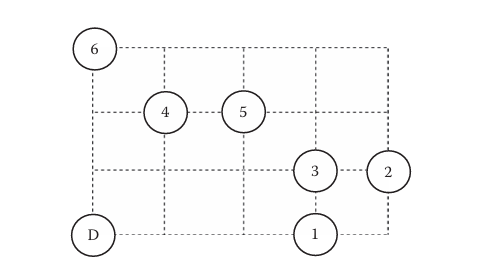

</div>

**Figure 4.12**  
Vehicle routing example.

<br>

Solving this as a linear program gives: z = 28 with x_2, x_4, x_6 = 1. The solution is integral by coincidence with $0 \leq x_i \leq 1$. The dual variables are (-2, -10, 0, -8, -10, 0). First, we will illustrate how we solve this problem. Later, we will illustrate why it works.

&nbsp;&nbsp;&nbsp;&nbsp;The duals, (one for each row, one for each customer), represent the sensitivity of the objective function to changes in the RHS. Increasing the RHS by 1 would result in an increase in the objective function of the corresponding dual variable. In our case, it would decrease the objective function because the duals are negative.

&nbsp;&nbsp;&nbsp;&nbsp;Consider the following special problem of finding a single route that starts at the depot, visits some customers, and returns to the depot in at most 10 hours. The cost of the route is the total time; however, for every customer that is visited, increase the cost by the corresponding dual variable. For example, a route that goes from “D” to “4” to “5” to “D” will cost: 8 - 8 - 10 = -10. We claim that if we had initially added a column with customers 4 and 5, and then computed the Simplex tableau for the current basic feasible solution, the new reduced cost would be precisely $-10$. Since it is negative, it can immediately enter the basis.

<br>

<div align="center">

<table style="font-size:20px; border-collapse:collapse; text-align:center; margin:auto;">
  <tr>
    <th style="padding:6px 16px; border-top:2px solid #666;"></th>
    <th colspan="7" style="padding:6px 16px; border-top:2px solid #666; border-bottom:1px solid #666;">Cost</th>
    <th style="padding:6px 16px; border-top:2px solid #666;"></th>
  </tr>
  <tr>
    <th style="padding:6px 16px;"></th>
    <th style="padding:6px 16px;">10</th>
    <th style="padding:6px 16px;">8</th>
    <th style="padding:6px 16px;">10</th>
    <th style="padding:6px 16px;">10</th>
    <th style="padding:6px 16px;">10</th>
    <th style="padding:6px 16px;">10</th>
    <th style="padding:6px 16px;">8</th>
    <th style="padding:6px 16px;"></th>
  </tr>
  <tr>
    <th style="padding:6px 16px; border-bottom:2px solid #666;">Customer</th>
    <th style="padding:6px 16px; border-bottom:2px solid #666;">x<sub>1</sub></th>
    <th style="padding:6px 16px; border-bottom:2px solid #666;">x<sub>2</sub></th>
    <th style="padding:6px 16px; border-bottom:2px solid #666;">x<sub>3</sub></th>
    <th style="padding:6px 16px; border-bottom:2px solid #666;">x<sub>4</sub></th>
    <th style="padding:6px 16px; border-bottom:2px solid #666;">x<sub>5</sub></th>
    <th style="padding:6px 16px; border-bottom:2px solid #666;">x<sub>6</sub></th>
    <th style="padding:6px 16px; border-bottom:2px solid #666;">x<sub>7</sub></th>
    <th style="padding:6px 16px; border-bottom:2px solid #666;">RHS</th>
  </tr>
  <tr>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;">1</td>
  </tr>
  <tr>
    <td style="padding:6px 16px;">2</td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;">1</td>
  </tr>
  <tr>
    <td style="padding:6px 16px;">3</td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;">1</td>
  </tr>
  <tr>
    <td style="padding:6px 16px;">4</td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;">1</td>
  </tr>
  <tr>
    <td style="padding:6px 16px;">5</td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;"></td>
    <td style="padding:6px 16px;">1</td>
    <td style="padding:6px 16px;">1</td>
  </tr>
  <tr>
    <td style="padding:6px 16px; border-bottom:2px solid #666;">6</td>
    <td style="padding:6px 16px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 16px; border-bottom:2px solid #666;">1</td>
    <td style="padding:6px 16px; border-bottom:2px solid #666;">1</td>
    <td style="padding:6px 16px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 16px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 16px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 16px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 16px; border-bottom:2px solid #666;">1</td>
  </tr>
</table>

</div>

<br>

&nbsp;&nbsp;&nbsp;&nbsp;Solving this as a linear program again gives: z = 28 with x_2, x_4, x_6 = 1. However, the dual variables are now(-10, 0, -10, 0, 0, -8). Again, by inspection, we find a new route with a negative reduced cost. The new column corresponds to “D” to “1” to “3” to “D” for a cost of 8 - 10 - 10 = -12.


Solving this as a linear program again gives z = 27; x_3, x_5, x_6, x_7, x_8 = 0.5. The new dual variables are now (-4, -6, -4, -3, -5, -5). By inspection again, we find a route with a negative reduced cost. The best negative reduced cost route corresponds to “D” to “5” to “4” to “6” to “D” for a cost of 10 - 5 - 3 - 5 = -3


&nbsp;&nbsp;&nbsp;&nbsp;After a few more iterations, we find a solution with z = 20 and x_9, x_{10} = 1 corresponding to two routes: customers $\{1,2,3\}$ and $\{4,5,6\}$. The final dual variables are (0, -2, -8, 0, -2, -8). The reader should verify that there are no feasible routes with a negative reduced cost, and therefore, this is the optimal solution to the LP. In fact, because this is by chance an integer solution, it is also the optimal integer solution.

<br>

<div align="center">

<table style="font-size:20px; border-collapse:collapse; text-align:center; margin:auto;">
  <tr>
    <th style="padding:6px 12px; border-top:2px solid #666;"></th>
    <th colspan="10" style="padding:6px 12px; border-top:2px solid #666; border-bottom:1px solid #666;">Cost</th>
    <th style="padding:6px 12px; border-top:2px solid #666;"></th>
  </tr>
  <tr>
    <th style="padding:6px 12px;"></th>
    <th style="padding:6px 12px;">10</th>
    <th style="padding:6px 12px;">8</th>
    <th style="padding:6px 12px;">10</th>
    <th style="padding:6px 12px;">10</th>
    <th style="padding:6px 12px;">10</th>
    <th style="padding:6px 12px;">10</th>
    <th style="padding:6px 12px;">8</th>
    <th style="padding:6px 12px;">8</th>
    <th style="padding:6px 12px;">10</th>
    <th style="padding:6px 12px;">10</th>
    <th style="padding:6px 12px;"></th>
  </tr>
  <tr>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">Customer</th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>1</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>2</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>3</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>4</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>5</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>6</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>7</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>8</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>9</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">x<sub>10</sub></th>
    <th style="padding:6px 12px; border-bottom:2px solid #666;">RHS</th>
  </tr>

  <tr>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;">1</td>
  </tr>

  <tr>
    <td style="padding:6px 12px;">2</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;">1</td>
  </tr>

  <tr>
    <td style="padding:6px 12px;">3</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;">1</td>
  </tr>

  <tr>
    <td style="padding:6px 12px;">4</td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
  </tr>

  <tr>
    <td style="padding:6px 12px;">5</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
    <td style="padding:6px 12px;"></td>
    <td style="padding:6px 12px;">1</td>
  </tr>

  <tr>
    <td style="padding:6px 12px; border-bottom:2px solid #666;">6</td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;">1</td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;">1</td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;">1</td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;"></td>
    <td style="padding:6px 12px; border-bottom:2px solid #666;">1</td>
  </tr>
</table>

</div>

<br>

Normally, column generation produces a fractional LP solution, and no new column can be created with a negative reduced cost. This means that no such column exists. Column generation is an optimal procedure for the linear programming problem. Moreover, the optimal solution to the LP is a lower bound on the optimal solution to the corresponding integer programming problem.

&nbsp;&nbsp;&nbsp;&nbsp;Current software packages with column generation use specialized software to solve the resulting partitioning problem optimally. Methods have been designed that use the special structure of the problem to solve very large problems to optimality. The solution is optimal for the given set of columns. There is no guarantee that there is no new column that could be added to produce a lower integer answer. However, the integer function value is often quite close to the linear function value. In general practice, column generation tends to produce very good solutions.

**Code Implementation**

In [ ]:
# Install required packages (run once in Colab)
!pip install pyomo --quiet
!apt-get install -y -qq coinor-cbc
!pip install scipy numpy --quiet

Selecting previously unselected package coinor-libcoinutils3v5:amd64.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../0-coinor-libcoinutils3v5_2.11.4+repack1-2_amd64.deb ...
Unpacking coinor-libcoinutils3v5:amd64 (2.11.4+repack1-2) ...
Selecting previously unselected package coinor-libosi1v5:amd64.
Preparing to unpack .../1-coinor-libosi1v5_0.108.6+repack1-2_amd64.deb ...
Unpacking coinor-libosi1v5:amd64 (0.108.6+repack1-2) ...
Selecting previously unselected package coinor-libclp1.
Preparing to unpack .../2-coinor-libclp1_1.17.5+repack1-1_amd64.deb ...
Unpacking coinor-libclp1 (1.17.5+repack1-1) ...
Selecting previously unselected package coinor-libcgl1:amd64.
Preparing to unpack .../3-coinor-libcgl1_0.60.3+repack1-3_amd64.deb ...
Unpacking coinor-libcgl1:amd64 (0.60.3+repack1-3) ...
Selecting previously unselected package coinor-libcbc3:amd64.
Preparing to unpack .../4-coinor-libcbc3_2.10.7+ds1-1_amd64.deb ...
Unpacking coinor-libcbc3:

In [ ]:
from pyomo.environ import *
import numpy as np

In [ ]:
from pyomo.environ import *

# Textbook initial columns — Section 4.8
# Each row = one customer (1-6), each col = one route
# A[i][j] = 1 if customer i is in route j
A_init = [
    #  x1 x2 x3 x4 x5 x6
    [  1, 0, 1, 0, 0, 0],  # customer 1
    [  1, 0, 0, 1, 0, 0],  # customer 2
    [  0, 1, 0, 1, 0, 0],  # customer 3
    [  0, 1, 0, 0, 1, 0],  # customer 4
    [  0, 0, 1, 0, 0, 1],  # customer 5
    [  0, 0, 0, 0, 1, 1],  # customer 6
]
cost_init = [10, 8, 10, 10, 10, 10]   # textbook costs

# Textbook additional columns (added during column generation iterations)
# x7: customers {4,5}, cost=8  (textbook: D→4→5→D)
# x8: customers {1,3}, cost=8  (textbook: D→1→3→D)
# x9: customers {1,2,3}, cost=10
# x10: customers {4,5,6}, cost=10
A_all = [
    [1, 0, 1, 0, 0, 0, 0, 1, 1, 0],  # customer 1
    [1, 0, 0, 1, 0, 0, 0, 0, 1, 0],  # customer 2
    [0, 1, 0, 1, 0, 0, 0, 1, 1, 0],  # customer 3
    [0, 1, 0, 0, 1, 0, 1, 0, 0, 1],  # customer 4
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 1],  # customer 5
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 1],  # customer 6
]
cost_all = [10, 8, 10, 10, 10, 10, 8, 8, 10, 10]

def solve_set_partition_lp(A, costs, label):
    n_routes = len(costs)
    m = ConcreteModel()
    m.J = RangeSet(1, n_routes)
    m.x = Var(m.J, bounds=(0, None))
    m.obj = Objective(expr=sum(costs[j-1]*m.x[j] for j in m.J), sense=minimize)
    def cover(m, i):
        return sum(A[i-1][j-1]*m.x[j] for j in m.J) >= 1
    m.cover = Constraint(RangeSet(1, 6), rule=cover)
    SolverFactory('cbc').solve(m)
    x_vals = [m.x[j].value for j in m.J]
    nonzero = {j+1: round(v, 3) for j, v in enumerate(x_vals) if v and v > 1e-6}
    print(f'  {label}: z = {m.obj():.1f},  routes used: {nonzero}')
    return m.obj(), x_vals

print('=== 4.8 Column Generation — Vehicle Routing ===')
print('\nInitial LP (6 textbook routes):')
solve_set_partition_lp(A_init, cost_init, 'Initial')

print('\nAfter adding columns x7 {4,5} and x8 {1,3} (textbook iterations):')
solve_set_partition_lp(
    [r[:8] for r in A_all], cost_all[:8], 'With x7, x8'
)

print('\nFinal — all textbook columns including x9 {1,2,3} and x10 {4,5,6}:')
solve_set_partition_lp(A_all, cost_all, 'Final LP')

# Integer solution with final columns
n_routes = len(cost_all)
m_ip = ConcreteModel()
m_ip.J = RangeSet(1, n_routes)
m_ip.x = Var(m_ip.J, within=NonNegativeIntegers)
m_ip.obj = Objective(expr=sum(cost_all[j-1]*m_ip.x[j] for j in m_ip.J), sense=minimize)
def cover_ip(m_ip, i):
    return sum(A_all[i-1][j-1]*m_ip.x[j] for j in m_ip.J) >= 1
m_ip.cover = Constraint(RangeSet(1, 6), rule=cover_ip)
SolverFactory('cbc').solve(m_ip)
routes_used = [j for j in m_ip.J if m_ip.x[j].value > 0.5]
route_names = ['x1{1,2}','x2{3,4}','x3{1,5}','x4{2,3}','x5{4,6}','x6{5,6}',
               'x7{4,5}','x8{1,3}','x9{1,2,3}','x10{4,5,6}']
print(f'\nInteger solution: z = {int(round(m_ip.obj()))}')
print(f'Routes: {[route_names[j-1] for j in routes_used]}')
print('Textbook answer: routes {1,2,3} and {4,5,6}, cost = 20')

=== 4.8 Column Generation — Vehicle Routing ===

Initial LP (6 textbook routes):
  Initial: z = 28.0,  routes used: {1: 1.0, 2: 1.0, 6: 1.0}

After adding columns x7 {4,5} and x8 {1,3} (textbook iterations):
  With x7, x8: z = 28.0,  routes used: {1: 1.0, 2: 1.0, 6: 1.0}

Final — all textbook columns including x9 {1,2,3} and x10 {4,5,6}:
  Final LP: z = 20.0,  routes used: {9: 1.0, 10: 1.0}

Integer solution: z = 20
Routes: ['x9{1,2,3}', 'x10{4,5,6}']
Textbook answer: routes {1,2,3} and {4,5,6}, cost = 20
